In [1]:
import copy
import functools
import glob
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import numpy as np
import os
import pandas as pd
import statsmodels.formula.api as smf

from matplotlib import style
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats, special
from sklearn import mixture
from sklearn import datasets
from tqdm import tqdm

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)

In [2]:
#!pip freeze > ../requirements.txt
#!pip install -r ../requirements.txt --user

In [3]:
DATA_FOLDER = "../data"
OUTPUT_FOLDER = "../output"

# Load Dictionary and Params

In [4]:
BIG_DICT_PATH = os.path.join(OUTPUT_FOLDER,"big_dict_colorado.p")
PARAMS_PATH = os.path.join(OUTPUT_FOLDER,"params_colorado.p")

with open(BIG_DICT_PATH,"rb+") as handle:
    big_dict = pickle.load(handle)
with open(PARAMS_PATH,"rb+") as handle:
    params = pickle.load(handle)


In [5]:
params

{'r_thresholds': array([-0.04652002, -0.03935008, -0.03218015, -0.02501022, -0.01784029,
        -0.01067036, -0.00350042,  0.00366951,  0.01083944,  0.01800937,
         0.0251793 ,  0.03234924,  0.03951917,  0.0466891 ,  0.05385903,
         0.06102896,  0.06819889,  0.07536883,  0.08253876,  0.08970869,
         0.09687862,  0.10404855,  0.11121849,  0.11838842,  0.12555835,
         0.13272828,  0.13989821,  0.14706815,  0.15423808,  0.16140801,
         0.16857794,  0.17574787,  0.18291781,  0.19008774,  0.19725767,
         0.2044276 ,  0.21159753,  0.21876746,  0.2259374 ,  0.23310733,
         0.24027726,  0.24744719,  0.25461712,  0.26178706,  0.26895699,
         0.27612692,  0.28329685,  0.29046678,  0.29763672,  0.30480665,
         0.31197658,  0.31914651,  0.32631644,  0.33348637,  0.34065631,
         0.34782624,  0.35499617,  0.3621661 ,  0.36933603,  0.37650597,
         0.3836759 ,  0.39084583,  0.39801576,  0.40518569,  0.41235563,
         0.41952556,  0.42669549,  

### Plot ROC for `lm, grf, gt` for different lookahead ranges

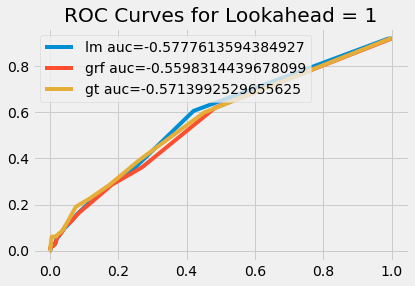

In [7]:
lookahead = 1
for classifier in params["classifiers"]:
    TPR_array = np.zeros(len(params["r_thresholds"]))
    FPR_array = np.zeros(len(params["r_thresholds"]))

    for i, r_threshold in enumerate(params["r_thresholds"]):
        FPR = big_dict[(classifier, r_threshold, lookahead)]["FPR"]
        TPR = big_dict[(classifier, r_threshold, lookahead)]["TPR"]
        TPR_array[i] = TPR
        FPR_array[i] = FPR
    auc = np.trapz(TPR_array,FPR_array)
    plt.plot(FPR_array,TPR_array, label=classifier + " auc={}".format(auc))
    plt.legend(loc="upper left")
    plt.xlabel="FPR"
    plt.ylabel="TPR"
    plt.title("ROC Curves for Lookahead = {}".format(lookahead))
plt.show()

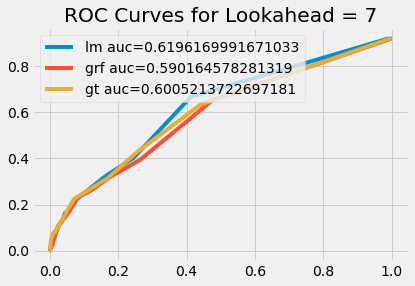

In [13]:
lookahead = 7
for classifier in params["classifiers"]:
    TPR_array = np.zeros(len(params["r_thresholds"]))
    FPR_array = np.zeros(len(params["r_thresholds"]))

    for i, r_threshold in enumerate(params["r_thresholds"]):
        FPR = big_dict[(classifier, r_threshold, lookahead)]["FPR"]
        TPR = big_dict[(classifier, r_threshold, lookahead)]["TPR"]
        TPR_array[i] = TPR
        FPR_array[i] = FPR
    auc = np.trapz(sorted(TPR_array),sorted(FPR_array))
    plt.plot(sorted(FPR_array),sorted(TPR_array), label=classifier + " auc={}".format(auc))
    plt.legend(loc="upper left")
    plt.xlabel="FPR"
    plt.ylabel="TPR"
    plt.title("ROC Curves for Lookahead = {}".format(lookahead))
plt.show()

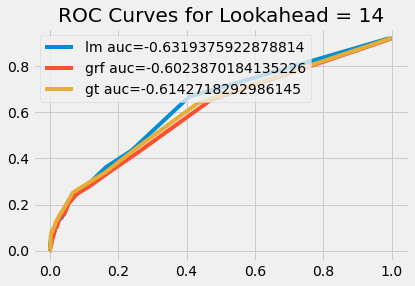

In [9]:
lookahead = 14
for classifier in params["classifiers"]:
    TPR_array = np.zeros(len(params["r_thresholds"]))
    FPR_array = np.zeros(len(params["r_thresholds"]))

    for i, r_threshold in enumerate(params["r_thresholds"]):
        FPR = big_dict[(classifier, r_threshold, lookahead)]["FPR"]
        TPR = big_dict[(classifier, r_threshold, lookahead)]["TPR"]
        TPR_array[i] = TPR
        FPR_array[i] = FPR
    auc = np.trapz(TPR_array,FPR_array)
    plt.plot(FPR_array,TPR_array, label=classifier + " auc={}".format(auc))
    plt.legend(loc="upper left")
    plt.xlabel="FPR"
    plt.ylabel="TPR"
    plt.title("ROC Curves for Lookahead = {}".format(lookahead))
plt.show()

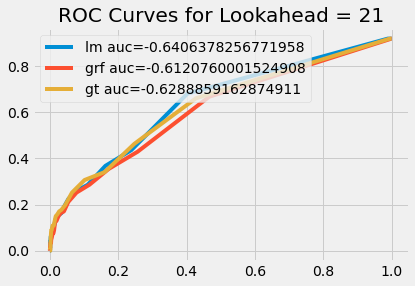

In [10]:
lookahead = 21
for classifier in params["classifiers"]:
    TPR_array = np.zeros(len(params["r_thresholds"]))
    FPR_array = np.zeros(len(params["r_thresholds"]))

    for i, r_threshold in enumerate(params["r_thresholds"]):
        FPR = big_dict[(classifier, r_threshold, lookahead)]["FPR"]
        TPR = big_dict[(classifier, r_threshold, lookahead)]["TPR"]
        TPR_array[i] = TPR
        FPR_array[i] = FPR
    auc = np.trapz(TPR_array,FPR_array)
    plt.plot(FPR_array,TPR_array, label=classifier + " auc={}".format(auc))
    plt.legend(loc="upper left")
    plt.xlabel="FPR"
    plt.ylabel="TPR"
    plt.title("ROC Curves for Lookahead = {}".format(lookahead))
plt.show()

In [11]:
TPR_array

array([0.91836735, 0.91836735, 0.91836735, 0.91836735, 0.91836735,
       0.91836735, 0.91836735, 0.65986395, 0.46258503, 0.34013605,
       0.30612245, 0.25170068, 0.19727891, 0.17687075, 0.17006803,
       0.15646259, 0.14965986, 0.1292517 , 0.10884354, 0.10884354,
       0.0952381 , 0.08843537, 0.08843537, 0.08163265, 0.06802721,
       0.05442177, 0.04081633, 0.02721088, 0.02040816, 0.01360544,
       0.00680272, 0.00680272, 0.00680272, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [12]:
FPR_array

array([1.00000000e+00, 9.99929063e-01, 9.99929063e-01, 9.99858126e-01,
       9.99432503e-01, 9.98155636e-01, 9.94679719e-01, 4.27183089e-01,
       2.46931971e-01, 1.59892176e-01, 1.01510960e-01, 6.46236788e-02,
       4.45484855e-02, 3.36241754e-02, 2.70270270e-02, 2.12811236e-02,
       1.70958360e-02, 1.40455416e-02, 1.13499326e-02, 7.94495283e-03,
       5.88777754e-03, 4.82372136e-03, 3.97247641e-03, 3.47591686e-03,
       2.90842023e-03, 2.19904944e-03, 1.84436405e-03, 1.77342697e-03,
       1.63155281e-03, 1.48967866e-03, 1.20593034e-03, 1.13499326e-03,
       9.93119103e-04, 9.93119103e-04, 9.93119103e-04, 9.93119103e-04,
       9.93119103e-04, 9.93119103e-04, 9.93119103e-04, 9.93119103e-04,
       8.51244946e-04, 7.80307867e-04, 7.09370788e-04, 7.09370788e-04,
       7.09370788e-04, 6.38433709e-04, 5.67496630e-04, 5.67496630e-04,
       4.96559552e-04, 4.96559552e-04, 3.54685394e-04, 2.83748315e-04,
       2.12811236e-04, 1.41874158e-04, 1.41874158e-04, 7.09370788e-05,
      